## HW 1: Sinusoids, Functions, Additive Synthesis (15 points)
For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [94]:
import numpy as np
from IPython.display import Audio, Image
#%run hide_toggle.ipynb
from scipy.io.wavfile import read
from scipy import signal
import matplotlib.pyplot as plt
fs = 44100

### Question 1 - Sinusoids (3 points)
Define the function, **genSine(f, ...)** that construct a sinusoid at frequency `f`.
The arguments should include:  
* amplitude, with default value of 1 (float)
* sample rate, with default value of 44.1kHz (float)
* time in seconds, with default value of 1 (float)
* phase offset, with default value of 0 (float)
    
and will return the numpy array containing the sinusoidal waveform.

Your function must check for appropriate input and handle any errors.
    

In [95]:
class InvalidInputError(Exception):
    pass
def genSine(f=None, t=1, A=1, phi=0, fs=44100):
    try:
        if (type(f) == float or type(f) == int) and (type(t) == float or type(t) == int) and (type(A) == float or type(A) == int) and (type(phi) == float or type(phi) == int) and (type(fs) == float or type(fs) == int):
            A = float(A)
            f = float(f)
            phi = float(phi)
            fs = float(fs)
            t = float(t)
            tone = A * np.sin(2*np.pi*f*np.arange(0,t,1/fs)+phi)
            return tone
        else:   
            raise InvalidInputError("Error: All values must be of type float or int!")
    except InvalidInputError as e:
        print(e)
    
genSine(440)

array([ 0.        ,  0.06264832,  0.12505052, ..., -0.18696144,
       -0.12505052, -0.06264832])

### Question 2 - Classical Waveform (5 points)
Define a function, **genWave(freq, t, numHarms=None, A=1, phi=0, fs=44100)**, that will create one of the fundamental waveforms (saw, triangle, or square) built from the combination of sinusoids at integer multiples of a fundamental frequency.  The arguments passed will be as follows:

* freq will be the frequency in Hz (int or float).
* t will be the length of time in seconds (int or float).
* numHarms will be the number of harmonics used. If no value is given (NoneType), you should create the maximum harmonics possible given the sampling rate

The function should return a numpy array. **You may not use existing waveform functions such as those in the `scipy` library.**

Your function must check for appropriate input and handle any errors.

Try to make your function as efficient as you can, but we will not take points off for a long run time. Be mindful by using NumPy functions rather than direct iteration.

*Hint: your function should use your genSine function

**Bonus: Expand this function to create any of the classical waveforms with a new argument "type" specifying which to build.

In [96]:
def genWave(freq=None, t=1, numHarm=1, A=1, phi=0, fs=44100, type='sine'):
    wave = np.zeros(int(fs*t))
    if (type == 'sine' or type == 'Sine'):
        for i in range(1, numHarm+1):
            wave += genSine(freq*i, t, A=A)
        return wave
    elif (type =='saw' or type == 'Saw'):
        for i in range(1, numHarm+1):
            wave += genSine(freq*i, t, A=A/i)
        return wave
    elif (type == 'triangle' or type == 'Triangle'):
        for i in range(1, numHarm+1):
            wave += genSine(freq*i, t, A=A/((i+2)**2))
            return wave
    elif (type == 'square' or type == 'Square'):
        for i in range(1, numHarm+1):
            wave += genSine(freq*i, t, A=A/(i+2))
            return wave
    else:
        raise InvalidInputError('Input is not valid. Numbers must be floats, waveform must be str.')
        
    
        
x = genWave(440, 5, 10, 1, 0, 44100, 'Sine')
Audio(x, rate=44100)


### Question 3 - Arpeggio (4 points)

Define the function arpegiateFreq(freq, dur), that will create a major scale arpeggio of a given frequency for a given length using your genWave() function. The arguments passed will be as follows:
* freq will be the starting/fundamental frequency in Hz (int or float)
* dur will be the length of time in seconds (int or float)

Reminder: a major scale arpeggio is built from the root, major third, and perfect 5th. You should divide the duration evenly amongst the three notes. 

The function should return a numpy array.

*Hint: your function will use the function(s) you just wrote*

Your function must check for appropriate input and handle any errors

**Bonus: Create a new function called arpegiateNote(scale, dur). Instead of the second input being frequency in Hz, the function should receive a note name like 'C'. You will need to convert this note to frequency. If you want to go the extra mile, make it case sensitive, such that an uppercase 'C' yields a C major arpeggio and lowercase 'c' yields a c minor arpeggio.

In [97]:
class InvalidInputError(Exception):
    pass
def arpeggiateFreq(freq=None, dur=1):
    try:
        if freq > fs/2:
            raise InvalidInputError('Frequency is above Nyquist; Will create aliasing.')
        elif freq < 0:
            raise InvalidInputError('Frequency is negative; please input a positive frequency.')
        elif freq == 0:
            raise InvalidInputError('Frequency is 0; audio will not playback.')
        elif dur <= 0:
            raise InvalidInputError('Duration set as 0; audio will not playback.')
        elif (type(freq) == int or type(freq) == float) and (type(dur) == int or type(dur) == float):
            arpeggio = np.zeros(int(fs))
        
            for i in range(3):
                if i == 0:
                    freq3 = freq * (2**(7/12))
                    y = genWave(freq3, dur/3)
                    arpeggio = np.concatenate((y, arpeggio))
                elif i == 1:
                    freq2 = freq * (2**(1/3))
                    y = genWave(freq2, dur/3)
                    arpeggio = np.concatenate((y, arpeggio))
                elif i == 2: 
                    freq1 = freq
                    y = genWave(freq1, dur/3)
                    arpeggio = np.concatenate((y, arpeggio))   
                else:
                    continue
                arpeggio = arpeggio[arpeggio != 0]
            return arpeggio
        else:
            raise InvalidInputError('Arguments must be of type int or float')
    except InvalidInputError as e:
        print(e)

        

x = arpeggiateFreq(440, 6)
Audio(x, rate=fs)


## Error handling tips and edge cases
What should happen if the frequency inputs to our functions would generate frequncies above Nyquist?

What should happen if our time inputs are negative? Or are 0?

What should happen if our frequencies are negative? Or are 0?

You should account for actual coding errors and errors that conceptually do not make sense.

### Section 4 - Using functions and graphing (3 points)
Create a 2 second F major arpeggio in an array named 'myArp'. Play back your audio.

In [98]:
myArp = arpeggiateFreq(349.23, 2)
x = len(myArp)
print(x)
Audio(myArp, rate=fs)

88197


Remove every 4th sample of 'myArp', save as a new array, 'skipped, and play back your audio. What happened to the audio?

In [99]:
indices = np.arange(len(myArp))
keep = indices[indices % 4 != 3]
skips = myArp[keep]
diff = len(myArp) - len(skips)
zeroDiff = np.zeros(diff)
skipped = np.concatenate((skips, zeroDiff))

x = len(skipped)
print(x)

Audio(skipped, rate = fs)

# The audio sped up and was pitched up. 

88197


Create a 2 Bb major arpeggio in an array named 'myArp2'. Play back your audio

In [100]:
myArp2 = arpeggiateFreq(466.16, 2)
x = len(myArp2)
print(x)
Audio(myArp2, rate=fs)

88197


Reverse 'myArp2' and save as a new array, 'reverse'. Play back your audio

In [101]:
reverse = myArp2[::-1]
x = len(reverse)
print(x)
Audio(reverse, rate=fs)

88197


Graph your 4 arrays on top of one another. Make sure to label the axis and plot against time. 

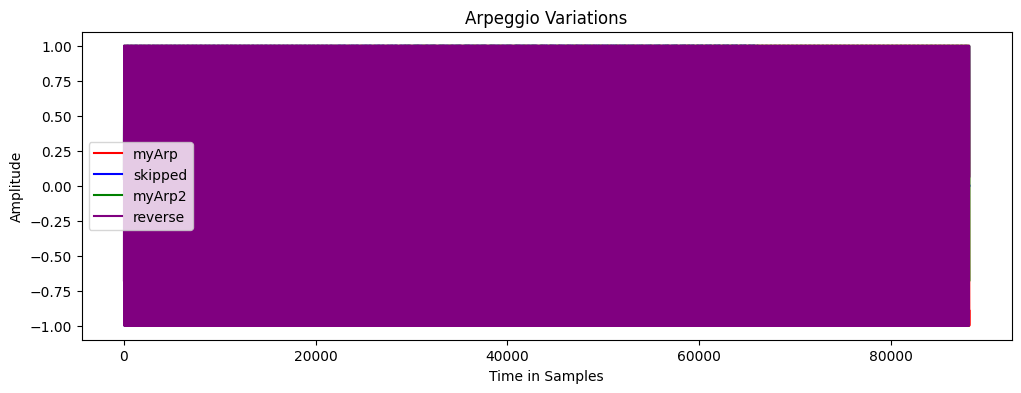

In [102]:
plt.figure(figsize=(12, 4))
plt.plot(myArp, label ='myArp', color='red')
plt.plot(skipped, label ='skipped', color='blue')
plt.plot(myArp2, label ='myArp2', color='green')
plt.plot(reverse, label ='reverse', color='purple')
plt.title('Arpeggio Variations')
plt.xlabel('Time in Samples')
plt.ylabel('Amplitude')
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()


Create another graph, but this time only plot the first "note" of each array

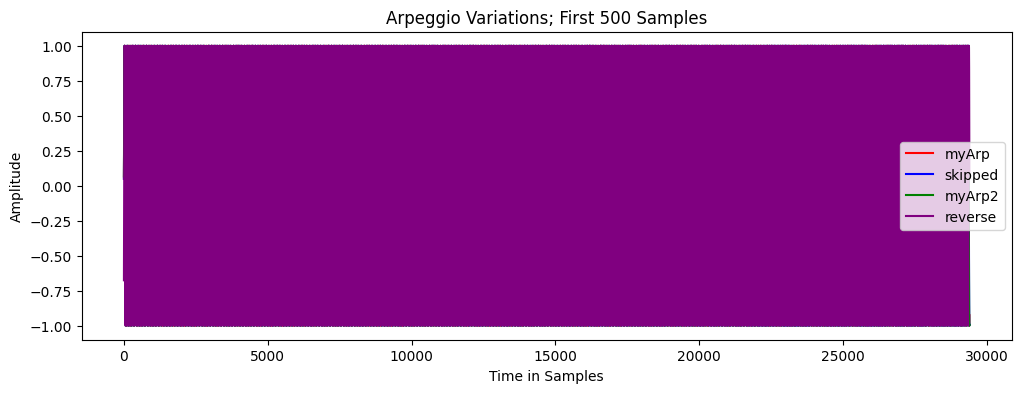

In [103]:
plt.figure(figsize=(12, 4))
plt.plot(myArp[:round(len(myArp)/3)], label ='myArp', color='red')
plt.plot(skipped[:round(len(skipped)/3)], label ='skipped', color='blue')
plt.plot(myArp2[:round(len(myArp2)/3)], label ='myArp2', color='green')
plt.plot(reverse[:round(len(reverse)/3)], label ='reverse', color='purple')
plt.title('Arpeggio Variations; First 500 Samples')
plt.xlabel('Time in Samples')
plt.ylabel('Amplitude')
plt.ylim(-1.1, 1.1)
plt.legend()
plt.show()



### GenAI Usage Statement (if applicable)